In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
from astropy.io import fits
# from astropy import stats
# import shutil
from astropy.visualization import simple_norm

from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.ndimage import shift
from matplotlib.colors import LogNorm

from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from astroquery.ipac.ned import Ned
import astropy.units as u
from astropy.nddata import Cutout2D
from scipy import interpolate
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from IPython.display import clear_output
# from pyBBarolo import *
from scipy import stats

from matplotlib.patches import Rectangle, ConnectionPatch

import warnings
from matplotlib import pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.utils.data import get_pkg_data_filename


In [124]:
angle_map, ha = fits.getdata("data/output/angle_map.fits", header=True)
distance_map, hd = fits.getdata("data/output/distance_map.fits", header=True)
residS, hs = fits.getdata("data/output/resid_star.fits", header=True)
resid, _ = fits.getdata("data/output/resid_HI.fits", header=True)
resid_mod, _ = fits.getdata("data/output/resid_CO.fits", header=True)
dataHa, hdr = fits.getdata("data/NGC1566_vel_Ha.fits", header=True)
F_Ha, hdr = fits.getdata("data/F_Ha.fits", header=True)
grad_phi, hdr = fits.getdata("data/output/grad_phi.fits", header=True)
grad_r, hdr = fits.getdata("data/output/grad_r.fits", header=True)
vel_grad_xy_mod, hdr = fits.getdata("data/output/vel_grad_xy_CO.fits", header=True)
model_vel_map_HI = fits.getdata("data/output/model_vel_map_HI.fits")
model_vel_map_mod = fits.getdata("data/output/model_vel_map_mod.fits")
model_vel_map_Ha = fits.getdata("data/output/model_vel_map_Ha.fits")

In [3]:
shift_vel = 25
incl = 32

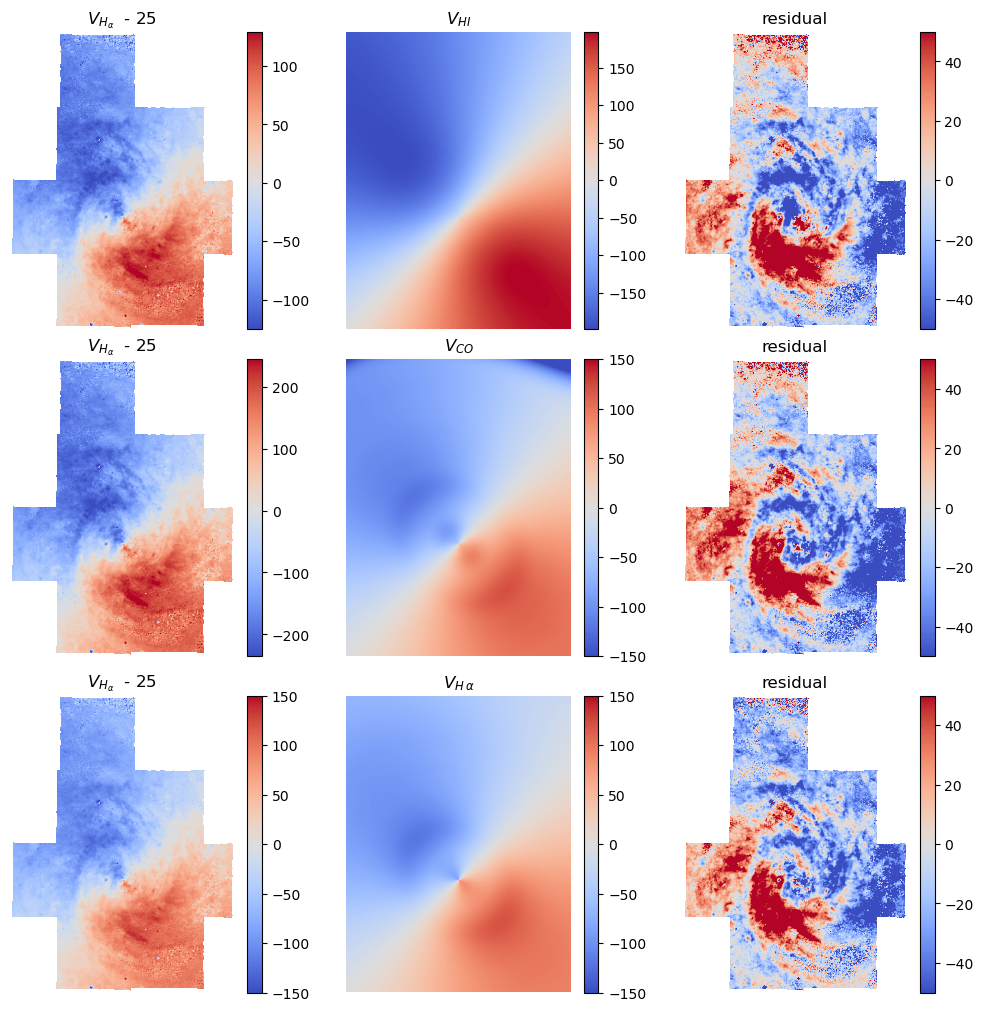

In [4]:
fig, axs = plt.subplots(3, 3, sharex=True, sharey=True, layout="constrained", figsize=(15, 10))
# fig.set_figheight(15)
fig.set_figwidth(10)

norm=simple_norm(dataHa - shift_vel, "linear", percent=99.)
im = axs[0, 0].imshow(dataHa - shift_vel, cmap='coolwarm', origin='lower', norm=norm)
fig.colorbar(im, ax=axs[0, 0])
# im.set_clim(vmin=-150, vmax=150)
axs[0, 0].axis("off")
axs[0, 0].set_title(r"$V_{H_{\alpha}}$ "+ f" - {shift_vel}")


norm=simple_norm(model_vel_map_HI, "linear", percent=99.)
im = axs[0, 1].imshow(model_vel_map_HI, cmap='coolwarm', origin='lower', norm=norm)
# im.set_clim(vmin=-80, vmax=80)
fig.colorbar(im, ax=axs[0, 1])
axs[0, 1].axis("off")
axs[0, 1].set_title(r"$V_{HI}$")

palette = ListedColormap(['#2b3cce','#4c5fdd','#6b80e8','#8ca0f2','#b0c1f9','#d6e1ff','#ffd8ca','#f1b6a1','#e2957b','#d07356','#bd5133','#a82a11'])
resid_HI= (dataHa - shift_vel)/np.sin(np.radians(incl)) - model_vel_map_HI
norm = simple_norm(resid_HI, "linear", percent=99)
im = axs[0, 2].imshow(resid_HI, cmap='coolwarm', origin='lower', norm = norm)
# im = axs[0, 2].imshow(resid, cmap=palette, origin='lower', norm = norm)
im.set_clim(vmin=-50, vmax=50)
fig.colorbar(im, ax=axs[0, 2])
axs[0, 2].axis("off")
axs[0, 2].set_title("residual")


# 2 pic

norm=simple_norm((dataHa - shift_vel)/np.sin(np.radians(incl)), "linear", percent=99.)
im = axs[1, 0].imshow((dataHa - shift_vel)/np.sin(np.radians(incl)), cmap='coolwarm', origin='lower', norm=norm)
fig.colorbar(im, ax=axs[1, 0])
# im.set_clim(vmin=-150, vmax=150)
axs[1, 0].axis("off")
axs[1, 0].set_title(r"$V_{H_{\alpha}}$ "+ f" - {shift_vel}")


norm=simple_norm(model_vel_map_mod*np.sin(np.radians(incl)), "linear", percent=99.)
im = axs[1, 1].imshow(model_vel_map_mod*np.sin(np.radians(incl)) , cmap='coolwarm', origin='lower', norm=norm)
im.set_clim(vmin=-150, vmax=150)
fig.colorbar(im, ax=axs[1, 1])
axs[1, 1].axis("off")
axs[1, 1].set_title(r"$V_{CO}$")

palette = ListedColormap(['#2b3cce','#4c5fdd','#6b80e8','#8ca0f2','#b0c1f9',"#d6d7ff",'#ffd8ca','#f1b6a1','#e2957b','#d07356','#bd5133','#a82a11'])
resid_mod = (dataHa - shift_vel)/np.sin(np.radians(incl)) - model_vel_map_mod
# resid = (dataHa- shift_vel)/np.sin(np.radians(incl)) - model_vel_map_mod
norm = simple_norm(resid_mod, "linear", percent=99)
im = axs[1, 2].imshow(resid_mod, cmap='coolwarm', origin='lower', norm = norm)
# im = axs[1, 2].imshow(resid, cmap=palette, origin='lower', norm = norm)
im.set_clim(vmin=-50, vmax=50)
fig.colorbar(im, ax=axs[1, 2])
axs[1, 2].axis("off")
# axs[1, 2].contour(F_Ha, [1000, 10000, 20000], colors="black")
axs[1, 2].set_title("residual")


# 3 pic


norm=simple_norm((dataHa - shift_vel), "linear", percent=99.)
im = axs[2, 0].imshow((dataHa - shift_vel), cmap='coolwarm', origin='lower', norm=norm)
fig.colorbar(im, ax=axs[2, 0])
im.set_clim(vmin=-150, vmax=150)
axs[2, 0].axis("off")
axs[2, 0].set_title(r"$V_{H_{\alpha}}$ "+ f" - {shift_vel}")


norm=simple_norm(model_vel_map_Ha*np.sin(np.radians(incl)), "linear", percent=99.)
im = axs[2, 1].imshow(model_vel_map_Ha*np.sin(np.radians(incl)) , cmap='coolwarm', origin='lower', norm=norm)
im.set_clim(vmin=-150, vmax=150)
fig.colorbar(im, ax=axs[2, 1])
axs[2, 1].axis("off")
axs[2, 1].set_title(r"$V_{H\,\alpha}$")

palette = ListedColormap(['#2b3cce','#4c5fdd','#6b80e8','#8ca0f2','#b0c1f9',"#d6d7ff",'#ffd8ca','#f1b6a1','#e2957b','#d07356','#bd5133','#a82a11'])
resid_mod = (dataHa - shift_vel)/np.sin(np.radians(incl)) - model_vel_map_Ha
# resid = (dataHa- shift_vel)/np.sin(np.radians(incl)) - model_vel_map_mod
norm = simple_norm(resid_mod, "linear", percent=99)
im = axs[2, 2].imshow(resid_mod, cmap='coolwarm', origin='lower', norm = norm)
# im = axs[1, 2].imshow(resid, cmap=palette, origin='lower', norm = norm)
im.set_clim(vmin=-50, vmax=50)
fig.colorbar(im, ax=axs[2, 2])
axs[2, 2].axis("off")
# axs[1, 2].contour(F_Ha, [1000, 10000, 20000], colors="black")

axs[2, 2].set_title("residual")

plt.show()

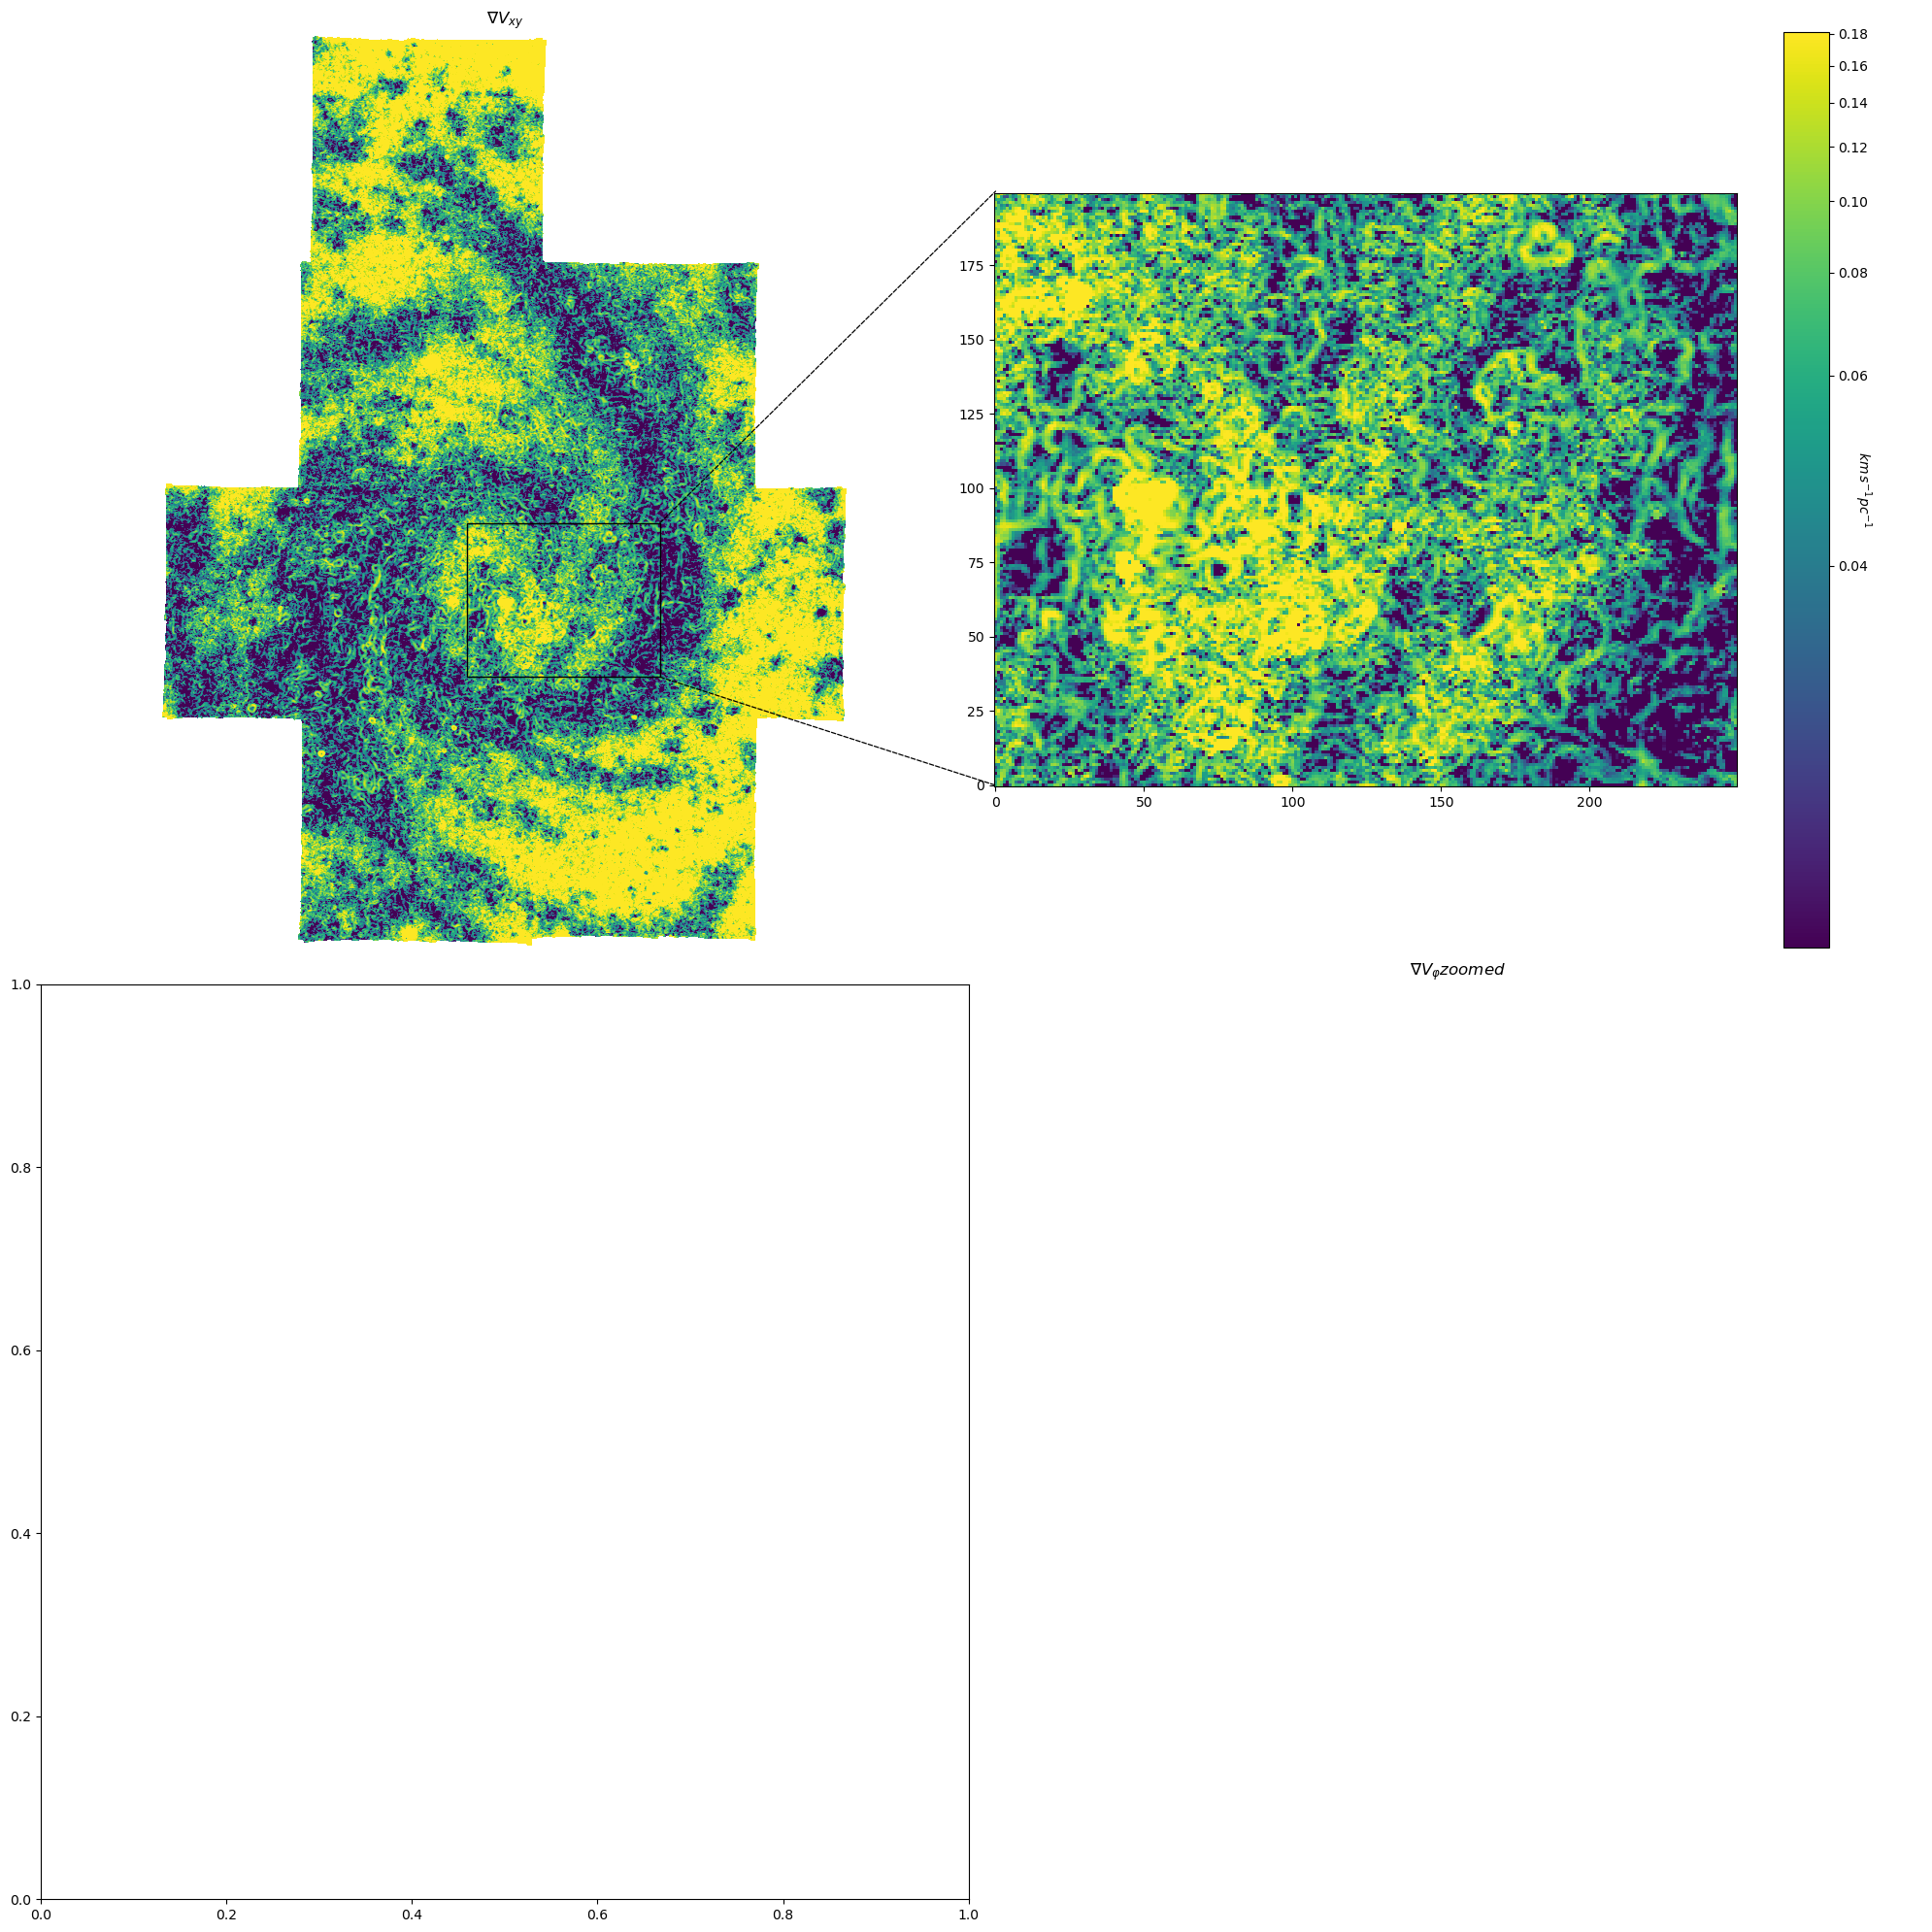

In [87]:
fig, ax = plt.subplots(2, 2, figsize=(20, 20))

# градиент скоростей
norm = simple_norm(vel_grad_xy_mod, "log", log_a=50, percent=70)
im = ax[0, 0].imshow(vel_grad_xy_mod, norm=norm, origin="lower")
# plt.colorbar(im)
# im.set_clim( vmax=1)

# ax[0, 0].contour(F_Ha, [900], colors="black")
ax[0, 0].set_title(r"$\nabla V_{xy}$")
ax[0, 0].axis("off")

# увеличенная область
zoom_area = (400, 350, 650, 550)
zoomed = vel_grad_xy_mod[zoom_area[1]:zoom_area[3], zoom_area[0]:zoom_area[2]]

im = ax[0, 1].imshow(zoomed, norm=norm, origin="lower")
cbar = plt.colorbar(im)
cbar.set_label(r"$km \, s^{-1} pc^{-1}$", rotation = 270)
# ax[0, 1].contour(F_Ha[zoom_area[1]:zoom_area[3], zoom_area[0]:zoom_area[2]], [900], colors="black")
# im.set_clim( vmax=1)
plt.title(r"$\nabla V_{\varphi} zoomed$")
plt.axis("off")

# рисуем рамочку для красоты))))
rect = Rectangle((zoom_area[0], zoom_area[1]), 
                 zoom_area[2]-zoom_area[0], 
                 zoom_area[3]-zoom_area[1],
                 linewidth=1, edgecolor='black', facecolor='none')
ax[0, 0].add_patch(rect)



# Соединяем 2 угла с настраиваемыми линиями (если раскомментить то 4 угла соединяются)
corners_main = [
    # (zoom_area[0], zoom_area[1]),  # левый нижний
    (zoom_area[2], zoom_area[1]),  # правый нижний
    (zoom_area[2], zoom_area[3]),  # правый верхний
    # (zoom_area[0], zoom_area[3])   # левый верхний
]

corners_zoom = [
    (0, 0),                        # левый нижний (в увеличенной области)
    # (zoomed.shape[1], 0),          # правый нижний
    # (zoomed.shape[1], zoomed.shape[0]),  # правый верхний
    (0, zoomed.shape[0])           # левый верхний
]

# Рисуем соединительные линии для всех углов
for (x1, y1), (x2, y2) in zip(corners_main, corners_zoom):
    con = ConnectionPatch(
        xyA=(x1, y1), coordsA=ax[0, 0].transData,
        xyB=(x2, y2), coordsB=ax[0, 1].transData,
        linestyle="--", linewidth=0.9, color="black",  # Стиль линии
        arrowstyle="-",  # Без стрелок (можно использовать "->")
        mutation_scale=20  # Размер стрелки, если используется
    )
    fig.add_artist(con)


 
plt.tight_layout()

In [99]:
print(hdr)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  898                                                  NAXIS2  =                 1187                                                  EXTEND  =                    T                                                  END                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [ ]:
scale = np.pi*20.3*1000/180/3600
print(scale)
pix_pc = 20.3*1000*np.pi/180* 5.55555*10**(-5)

# grad_phi = grad_phi/1000/scale
# vel_grad_xy_mod = vel_grad_xy_mod*1000*scale
# vel_grad_xy_mod = vel_grad_xy_mod/1000

0.09841717726523581


In [44]:
vel_grad_xy_mod[500:555, 500:555]

array([[0.05306314, 0.03991424, 0.03145789, ..., 0.05486104, 0.10388823,
        0.10262886],
       [0.04356838, 0.02529244, 0.04776737, ..., 0.09752421, 0.09857749,
        0.05401408],
       [0.00937612, 0.02207679, 0.04111231, ..., 0.08323267, 0.06348864,
        0.04318287],
       ...,
       [0.0356898 , 0.02904672, 0.02748165, ..., 0.07681094, 0.16825735,
        0.13321818],
       [0.0389752 , 0.03540703, 0.03223898, ..., 0.04920815, 0.12064626,
        0.21420186],
       [0.02205703, 0.01901232, 0.02355602, ..., 0.04068074, 0.12451063,
        0.12984315]], dtype='>f8')

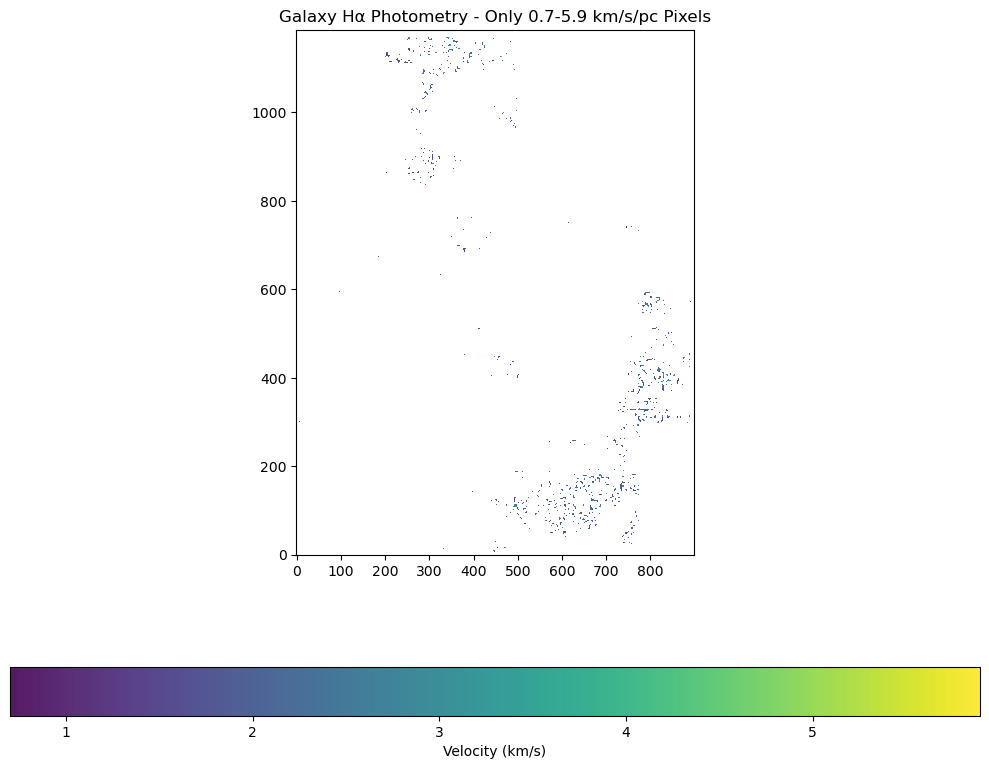

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.close()
# Создаем маску: оставляем только пиксели со скоростью от 30 до 50
min_velocity = 0.7
max_velocity = 5.9
# Создаем копию исходной карты скоростей
velocity_mask = vel_grad_xy_mod.copy()

# Заменяем все значения вне диапазона 30-50 на NaN
velocity_mask[(vel_grad_xy_mod < min_velocity) | (vel_grad_xy_mod > max_velocity)] = np.nan

# Визуализация
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Фотометрия
# norm = simple_norm(F_Ha, "log", percent=99)
# im1 = ax.imshow(F_Ha, cmap='grey', origin='lower', norm=norm)
# plt.colorbar(im1, ax=ax, label='Hα Flux', orientation='horizontal')

# Маска скоростей (только пиксели со скоростью 30-50) 
norm = simple_norm(velocity_mask, "log", log_a=50, percent=99)

im2 = ax.imshow(velocity_mask, alpha=0.9, origin='lower')
# im2.set_clim(vmax = 1)

plt.colorbar(im2, ax=ax, label='Velocity (km/s)', orientation='horizontal')

ax.set_title(f'Galaxy Hα Photometry - Only {min_velocity}-{max_velocity} km/s/pc Pixels')
plt.tight_layout()
plt.show()

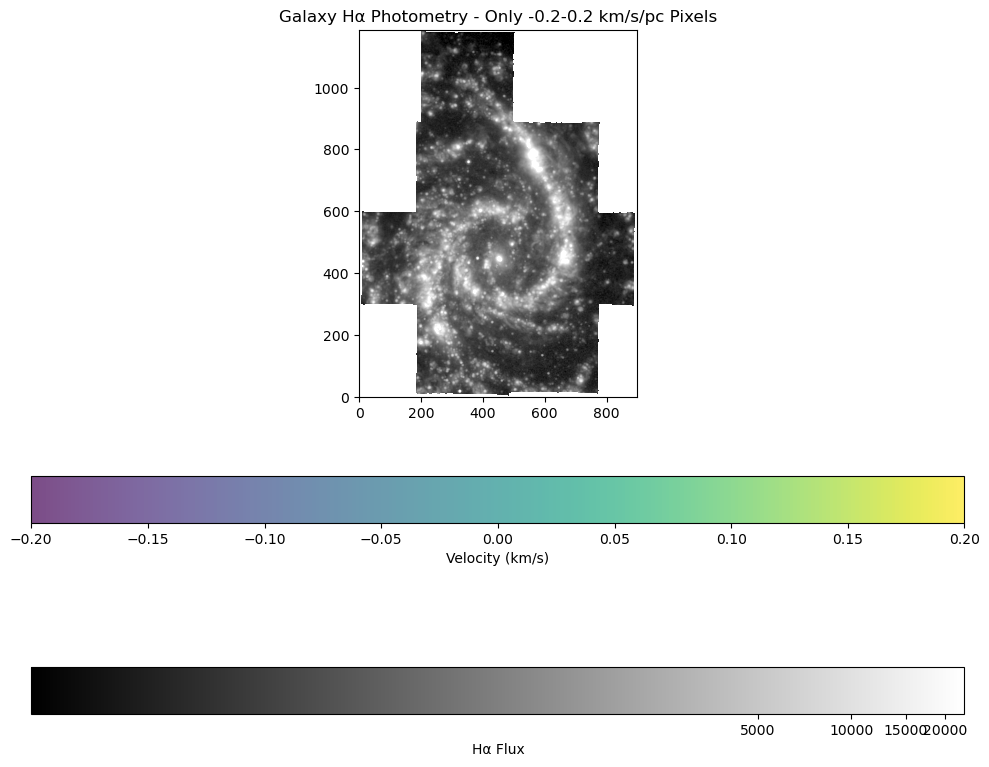

In [9]:
import matplotlib.pyplot as plt
import numpy as np


# Создаем маску: оставляем только пиксели со скоростью от 30 до 50
min_velocity = -0.2
max_velocity = 0.2

# Создаем копию исходной карты скоростей
velocity_mask = grad_phi.copy()

# Заменяем все значения вне диапазона 30-50 на NaN
velocity_mask[(grad_phi < min_velocity) | (grad_phi > max_velocity)] = np.nan

# Визуализация
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Фотометрия
norm = simple_norm(F_Ha, "log", percent=99)
im1 = ax.imshow(F_Ha, cmap='grey', origin='lower', norm=norm)
plt.colorbar(im1, ax=ax, label='Hα Flux', orientation='horizontal')

# Маска скоростей (только пиксели со скоростью 30-50)
im2 = ax.imshow(velocity_mask, alpha=0.7, 
                vmin=min_velocity, vmax=max_velocity, origin='lower')

plt.colorbar(im2, ax=ax, label='Velocity (km/s)', orientation='horizontal')

ax.set_title(f'Galaxy Hα Photometry - Only {min_velocity}-{max_velocity} km/s/pc Pixels')
plt.tight_layout()
plt.show()

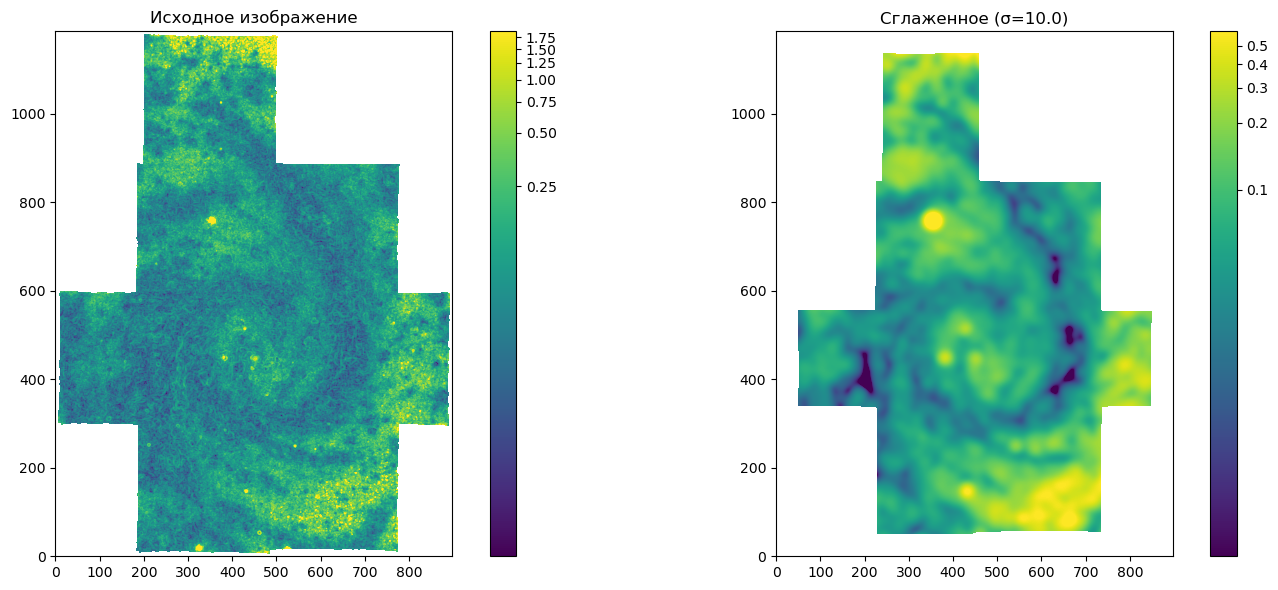

In [128]:
from scipy import ndimage
import matplotlib.pyplot as plt


# Ваше изображение 2000x2000
image = vel_grad_xy_mod

# Сглаживание гауссовым фильтром
sigma = 10.0  # Стандартное отклонение - чем больше, тем сильнее сглаживание
smoothed_image = ndimage.gaussian_filter(image, sigma=sigma)

# Сравнение
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Исходное изображение
norm = simple_norm(image, "log", percent=99)
im1 = axes[0].imshow(image, cmap='viridis', origin='lower', norm=norm)
axes[0].set_title('Исходное изображение')
plt.colorbar(im1, ax=axes[0])

# Сглаженное изображение
norm = simple_norm(smoothed_image, "log", percent=99)

im2 = axes[1].imshow(smoothed_image, cmap='viridis', origin='lower', norm=norm)
axes[1].set_title(f'Сглаженное (σ={sigma})')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()